> AI attribution: This notebook contains AI-assisted analysis/code that was reviewed, debugged, and validated by the author. See `ATTRIBUTION.md`.


# 03 — Neural Models: SimpleLSTM & DeepLOB

Trains both neural models at all 5 prediction horizons using early stopping on validation weighted-F1.
Saves the best checkpoint per horizon to `models/`.

**This notebook is long-running. On Apple Silicon MPS, expect roughly:**
- SimpleLSTM: ~15–30 min total across 5 horizons
- DeepLOB: ~1–3 hours total across 5 horizons

Run cells for each horizon independently so you can monitor progress and
checkpoints are saved even if later training is interrupted.

In [1]:
import subprocess, sys, os
reqs = os.path.expanduser("~/deeplob-midprice-prediction/requirements.txt")
subprocess.run([sys.executable, "-m", "pip", "install", "-r", reqs])



Defaulting to user installation because normal site-packages is not writeable


CompletedProcess(args=['/usr/pkg/miniconda-23.9.0/bin/python', '-m', 'pip', 'install', '-r', '/home/users/mt487/deeplob-midprice-prediction/requirements.txt'], returncode=0)

In [2]:
import sys, os
import socket
if socket.gethostname().startswith('compsci'):
    PROJECT_ROOT = os.path.expanduser('~/deeplob-midprice-prediction')
else:
    PROJECT_ROOT = os.path.expanduser('~/CS372/deeplob-midprice-prediction')

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import torch
import matplotlib.pyplot as plt

from src.data_loader import load_raw, extract_features_labels, temporal_split, SlidingWindowDataset, make_loader
from src.models.lstm_baseline import SimpleLSTM
from src.models.deeplob import DeepLOB
from src.train import train_neural, save_checkpoint, DEVICE
from src.evaluate import compute_metrics

MODELS  = os.path.join(PROJECT_ROOT, 'models')
RESULTS = os.path.join(PROJECT_ROOT, 'results')
DATA    = os.path.join(PROJECT_ROOT, 'data', 'raw')
os.makedirs(MODELS, exist_ok=True)
os.makedirs(RESULTS, exist_ok=True)

HORIZONS   = [1, 2, 3, 5, 10]
WINDOW     = 100
BATCH_SIZE = 256

print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device: cuda
PyTorch: 2.1.0


## 1. Load data and build datasets

In [ ]:
train_df = load_raw(os.path.join(DATA, 'FI2010_train.csv'))
test_df  = load_raw(os.path.join(DATA, 'FI2010_test.csv'))

X_all, Y_all   = extract_features_labels(train_df)
X_test, Y_test = extract_features_labels(test_df)

X_train, Y_train, X_val, Y_val = temporal_split(X_all, Y_all)

print(f'Train rows: {len(X_train):,}  →  {len(X_train) - WINDOW + 1:,} windows')
print(f'Val rows:   {len(X_val):,}   →  {len(X_val) - WINDOW + 1:,} windows')
print(f'Test rows:  {len(X_test):,}   →  {len(X_test) - WINDOW + 1:,} windows')

Train rows: 308,040  →  307,940 windows
Val rows:   54,360   →  54,260 windows
Test rows:  31,937   →  31,837 windows


## 2. Verify DeepLOB parameter count

Our PyTorch port has **60,947** parameters vs. the paper's 60,691. The difference is exactly 256:
PyTorch's `nn.LSTM` uses two bias vectors per layer (`b_ih` and `b_hh`, 64 values each × 4 gates = 256 extra),
while Keras/TensorFlow counts only one. The architecture is otherwise identical to the paper.

In [4]:
model = DeepLOB()
total_params = sum(p.numel() for p in model.parameters())
print(f'DeepLOB total parameters: {total_params:,}')
print(f'Paper (Keras):            60,691')
print(f'Difference:               {total_params - 60_691}  '
      f'(PyTorch LSTM has b_ih + b_hh; Keras has one bias — 4 gates × 64 units = 256)')
assert total_params == 60_947, f'Unexpected param count: {total_params}'
print('✓ Param count confirmed (60,947 = paper 60,691 + 256 LSTM bias)')

# Forward pass sanity check with the same shape DataLoader produces
dummy = torch.randn(2, 100, 40)
out   = model(dummy)
print(f'Forward pass: {tuple(dummy.shape)} → {tuple(out.shape)}  (expected [2, 3])')

DeepLOB total parameters: 60,947
Paper (Keras):            60,691
Difference:               256  (PyTorch LSTM has b_ih + b_hh; Keras has one bias — 4 gates × 64 units = 256)
✓ Param count confirmed (60,947 = paper 60,691 + 256 LSTM bias)
Forward pass: (2, 100, 40) → (2, 3)  (expected [2, 3])


/usr/pkg/miniconda-23.9.0/lib/python3.11/site-packages/torch/nn/modules/conv.py:456: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /opt/conda/conda-bld/pytorch_1695392035891/work/aten/src/ATen/native/Convolution.cpp:1008.)
  return F.conv2d(input, weight, bias, self.stride,


## 3. Helper: plot training curves

In [5]:
def plot_training_curves(history: dict, model_name: str, k: int, save_path: str = None):
    """Plot train loss, val loss, and val F1 per epoch."""
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history['train_loss'], label='Train loss', color='steelblue')
    axes[0].plot(epochs, history['val_loss'],   label='Val loss',   color='orange')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-entropy loss')
    axes[0].set_title(f'{model_name} k={k} — Loss')
    axes[0].legend()

    axes[1].plot(epochs, history['val_f1'], color='green')
    axes[1].axhline(max(history['val_f1']), color='green', linestyle='--', alpha=0.4,
                    label=f'Best F1 = {max(history["val_f1"]):.4f}')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Weighted F1')
    axes[1].set_title(f'{model_name} k={k} — Val F1')
    axes[1].legend()

    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    plt.close()

## 4. Train SimpleLSTM — all 5 horizons

2-layer LSTM, hidden=64, dropout=0.1. Early stopping patience=20 on val weighted-F1.
Adam lr=0.01, eps=1.0.


══════════ SimpleLSTM  k=1 ══════════
  epoch   1  tr_loss=0.8991  val_loss=0.8246  val_F1=0.5941  (22.0s)
  epoch   5  tr_loss=0.8894  val_loss=0.8186  val_F1=0.5941  (20.9s)
  epoch  10  tr_loss=0.8489  val_loss=0.8224  val_F1=0.5941  (21.4s)
  epoch  15  tr_loss=0.7545  val_loss=0.8247  val_F1=0.5945  (20.9s)
  epoch  20  tr_loss=0.7282  val_loss=0.7958  val_F1=0.6278  (17.1s)
  epoch  25  tr_loss=0.6956  val_loss=0.7319  val_F1=0.7052  (21.3s)
  epoch  30  tr_loss=0.6739  val_loss=0.6986  val_F1=0.7176  (21.2s)
  epoch  35  tr_loss=0.6574  val_loss=0.6784  val_F1=0.7241  (20.8s)
  epoch  40  tr_loss=0.6444  val_loss=0.6752  val_F1=0.7283  (21.4s)
  epoch  45  tr_loss=0.6335  val_loss=0.6536  val_F1=0.7282  (20.6s)
  epoch  50  tr_loss=0.6249  val_loss=0.6504  val_F1=0.7309  (20.3s)
  epoch  55  tr_loss=0.6180  val_loss=0.6408  val_F1=0.7314  (22.0s)
  epoch  60  tr_loss=0.6102  val_loss=0.6317  val_F1=0.7310  (20.1s)
  epoch  65  tr_loss=0.6054  val_loss=0.6329  val_F1=0.7337  (21

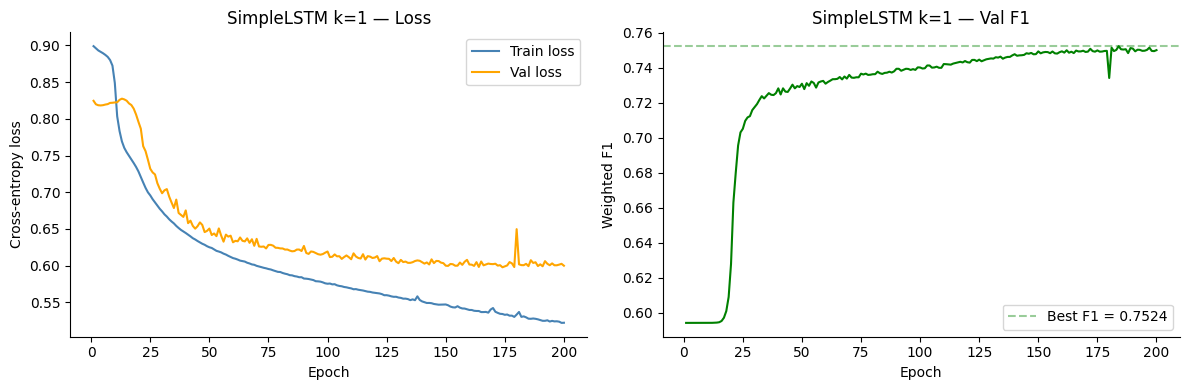


══════════ SimpleLSTM  k=2 ══════════
  epoch   1  tr_loss=1.0008  val_loss=0.9500  val_F1=0.4853  (21.7s)
  epoch   5  tr_loss=0.9892  val_loss=0.9458  val_F1=0.4857  (18.5s)
  epoch  10  tr_loss=0.9732  val_loss=0.9479  val_F1=0.4860  (20.5s)
  epoch  15  tr_loss=0.9168  val_loss=0.9527  val_F1=0.4866  (20.9s)
  epoch  20  tr_loss=0.8824  val_loss=0.9539  val_F1=0.4962  (21.0s)
  epoch  25  tr_loss=0.8618  val_loss=0.9301  val_F1=0.5482  (20.8s)
  epoch  30  tr_loss=0.8389  val_loss=0.8908  val_F1=0.6090  (19.5s)
  epoch  35  tr_loss=0.8181  val_loss=0.8425  val_F1=0.6251  (20.3s)
  epoch  40  tr_loss=0.8022  val_loss=0.7977  val_F1=0.6319  (20.9s)
  epoch  45  tr_loss=0.7925  val_loss=0.7897  val_F1=0.6385  (20.4s)
  epoch  50  tr_loss=0.7838  val_loss=0.7806  val_F1=0.6405  (20.1s)
  epoch  55  tr_loss=0.7791  val_loss=0.7805  val_F1=0.6442  (21.6s)
  epoch  60  tr_loss=0.7716  val_loss=0.7762  val_F1=0.6468  (20.4s)
  epoch  65  tr_loss=0.7661  val_loss=0.7752  val_F1=0.6480  (20

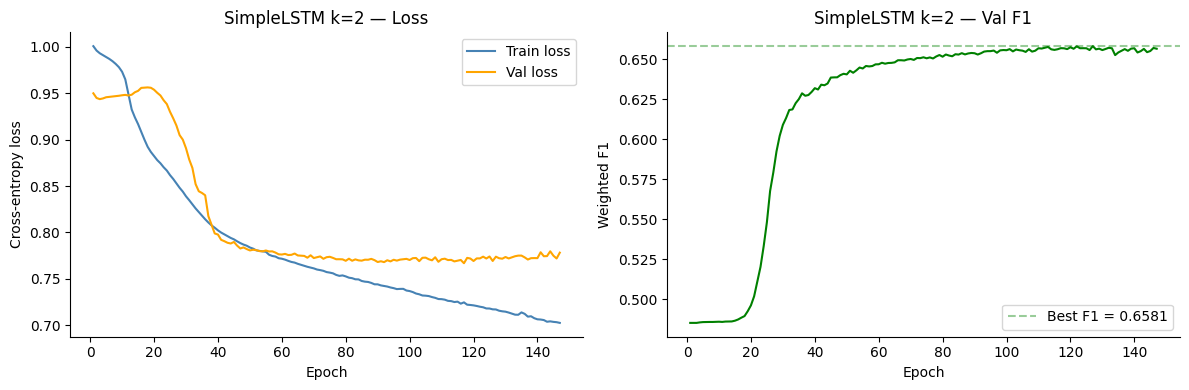


══════════ SimpleLSTM  k=3 ══════════
  epoch   1  tr_loss=1.0417  val_loss=1.0098  val_F1=0.4129  (21.6s)
  epoch   5  tr_loss=1.0142  val_loss=1.0087  val_F1=0.4171  (21.1s)
  epoch  10  tr_loss=0.9245  val_loss=1.0164  val_F1=0.4427  (18.9s)
  epoch  15  tr_loss=0.8642  val_loss=0.9638  val_F1=0.5752  (21.2s)
  epoch  20  tr_loss=0.8189  val_loss=0.8774  val_F1=0.6129  (20.6s)
  epoch  25  tr_loss=0.7872  val_loss=0.8216  val_F1=0.6283  (21.2s)
  epoch  30  tr_loss=0.7664  val_loss=0.8133  val_F1=0.6356  (20.3s)
  epoch  35  tr_loss=0.7506  val_loss=0.8123  val_F1=0.6391  (21.3s)
  epoch  40  tr_loss=0.7380  val_loss=0.8086  val_F1=0.6419  (17.9s)
  epoch  45  tr_loss=0.7269  val_loss=0.8065  val_F1=0.6433  (20.6s)
  epoch  50  tr_loss=0.7178  val_loss=0.7972  val_F1=0.6453  (20.9s)
  epoch  55  tr_loss=0.7103  val_loss=0.7999  val_F1=0.6448  (21.7s)
  epoch  60  tr_loss=0.7033  val_loss=0.7964  val_F1=0.6469  (21.6s)
  epoch  65  tr_loss=0.6963  val_loss=0.7966  val_F1=0.6469  (21

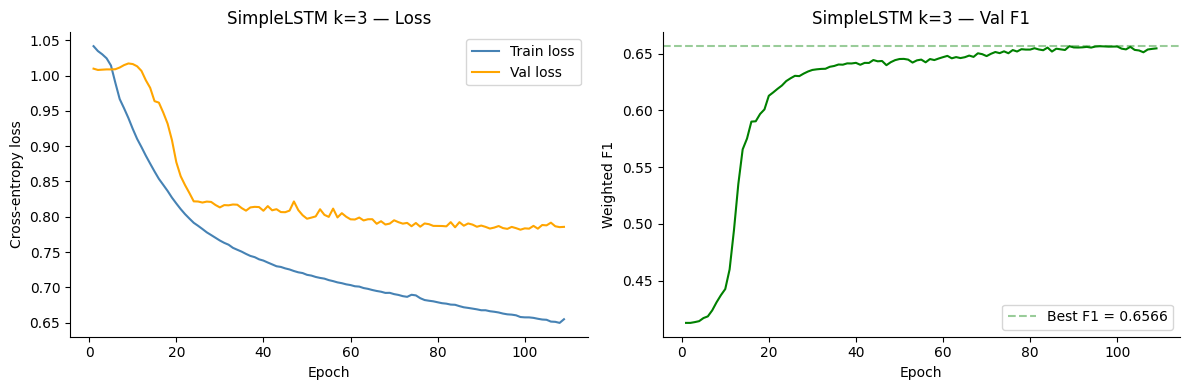


══════════ SimpleLSTM  k=5 ══════════
  epoch   1  tr_loss=1.0653  val_loss=1.0777  val_F1=0.3252  (18.2s)
  epoch   5  tr_loss=0.9849  val_loss=1.0719  val_F1=0.4556  (20.1s)
  epoch  10  tr_loss=0.8981  val_loss=1.0361  val_F1=0.5160  (20.8s)
  epoch  15  tr_loss=0.8222  val_loss=0.9647  val_F1=0.5777  (21.6s)
  epoch  20  tr_loss=0.7591  val_loss=0.8717  val_F1=0.6049  (20.4s)
  epoch  25  tr_loss=0.7235  val_loss=0.8429  val_F1=0.6215  (17.3s)
  epoch  30  tr_loss=0.6972  val_loss=0.8325  val_F1=0.6252  (21.4s)
  epoch  35  tr_loss=0.6766  val_loss=0.8196  val_F1=0.6312  (20.2s)
  epoch  40  tr_loss=0.6610  val_loss=0.8145  val_F1=0.6350  (21.5s)
  epoch  45  tr_loss=0.6471  val_loss=0.8106  val_F1=0.6360  (21.8s)
  epoch  50  tr_loss=0.6345  val_loss=0.8034  val_F1=0.6397  (21.2s)
  epoch  55  tr_loss=0.6224  val_loss=0.8034  val_F1=0.6409  (19.9s)
  epoch  60  tr_loss=0.6124  val_loss=0.8052  val_F1=0.6402  (19.3s)
  epoch  65  tr_loss=0.6035  val_loss=0.8093  val_F1=0.6384  (19

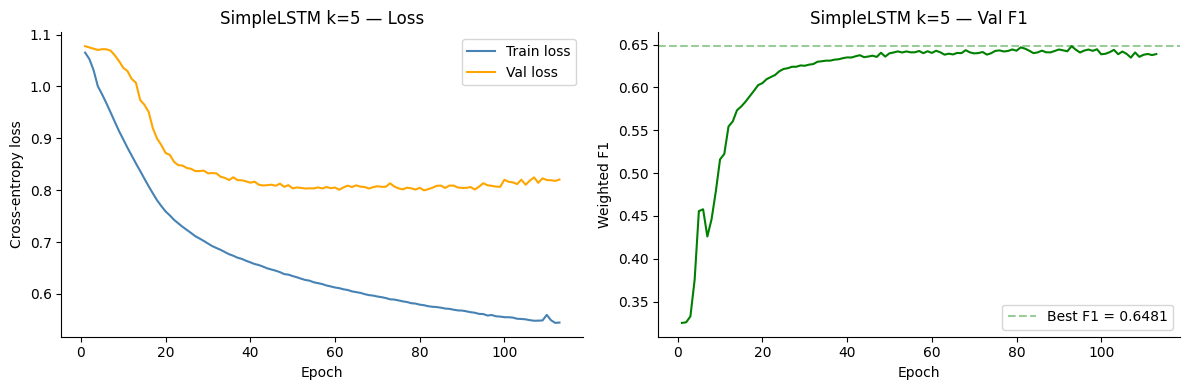


══════════ SimpleLSTM  k=10 ══════════
  epoch   1  tr_loss=1.0307  val_loss=1.1135  val_F1=0.2730  (18.5s)
  epoch   5  tr_loss=0.9518  val_loss=1.1139  val_F1=0.2846  (20.3s)
  epoch  10  tr_loss=0.8516  val_loss=1.1058  val_F1=0.2931  (20.7s)
  epoch  15  tr_loss=0.7905  val_loss=1.0872  val_F1=0.3132  (20.9s)
  epoch  20  tr_loss=0.7371  val_loss=1.0430  val_F1=0.4500  (20.5s)
  epoch  25  tr_loss=0.6798  val_loss=0.9471  val_F1=0.5613  (21.2s)
  epoch  30  tr_loss=0.6425  val_loss=0.8927  val_F1=0.5857  (19.6s)
  epoch  35  tr_loss=0.6199  val_loss=0.8781  val_F1=0.5922  (20.8s)
  epoch  40  tr_loss=0.5922  val_loss=0.8761  val_F1=0.5905  (20.3s)
  epoch  45  tr_loss=0.5707  val_loss=0.8673  val_F1=0.5998  (21.2s)
  epoch  50  tr_loss=0.5522  val_loss=0.8570  val_F1=0.6068  (20.2s)
  epoch  55  tr_loss=0.5373  val_loss=0.8431  val_F1=0.6209  (20.9s)
  epoch  60  tr_loss=0.5247  val_loss=0.8529  val_F1=0.6151  (18.8s)
  epoch  65  tr_loss=0.5128  val_loss=0.8448  val_F1=0.6226  (2

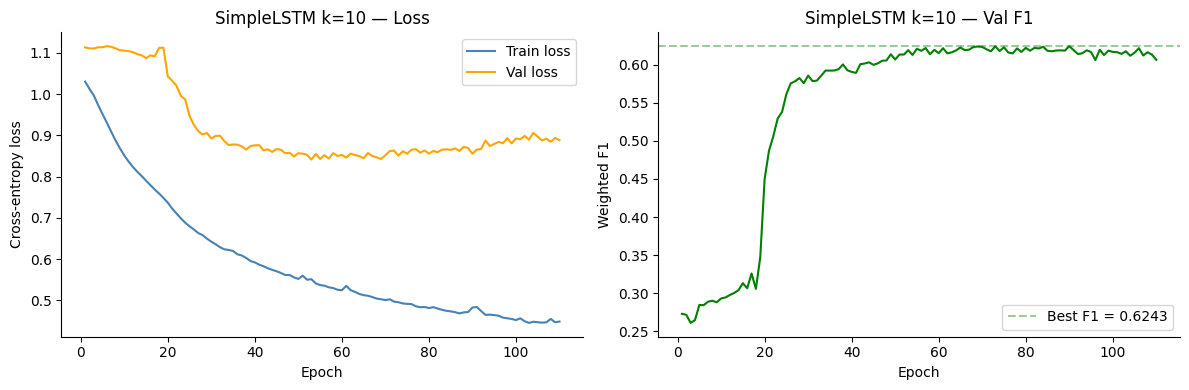

In [7]:
lstm_results  = []
lstm_histories = []

for h_idx, k in enumerate(HORIZONS):
    print(f'\n══════════ SimpleLSTM  k={k} ══════════')

    train_ds = SlidingWindowDataset(X_train, Y_train, window=WINDOW, horizon_idx=h_idx)
    val_ds   = SlidingWindowDataset(X_val,   Y_val,   window=WINDOW, horizon_idx=h_idx)
    test_ds  = SlidingWindowDataset(X_test,  Y_test,  window=WINDOW, horizon_idx=h_idx)

    train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
    val_loader   = make_loader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
    test_loader  = make_loader(test_ds,  batch_size=512,        shuffle=False)

    model = SimpleLSTM()
    best_state, history = train_neural(
        model, train_loader, val_loader,
        max_epochs=200, patience=20,
        lr=0.01, eps=1.0,
        device=DEVICE, verbose=True
    )

    # Save checkpoint
    ckpt_path = os.path.join(MODELS, f'lstm_k{k}.pt')
    save_checkpoint(best_state, ckpt_path)
    print(f'  Saved → {ckpt_path}')

    # Evaluate on test set
    model.load_state_dict(best_state)
    model.eval().to(DEVICE)
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            all_preds.append(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
            all_labels.append(yb.numpy())
    import numpy as np
    preds  = np.concatenate(all_preds)
    labels = np.concatenate(all_labels)
    metrics = compute_metrics(labels, preds)
    lstm_results.append(metrics)
    lstm_histories.append(history)
    print(f'  TEST  weighted_F1={metrics["weighted_f1"]:.4f}  kappa={metrics["cohen_kappa"]:.4f}')

    plot_training_curves(history, 'SimpleLSTM', k,
                         save_path=os.path.join(RESULTS, f'lstm_curves_k{k}.png'))

### SimpleLSTM — results across horizons

In [23]:
from src.data_loader import load_raw, extract_features_labels, SlidingWindowDataset, make_loader
from src.models.lstm_baseline import SimpleLSTM
from src.train import load_checkpoint, DEVICE
from src.evaluate import compute_metrics
import torch

test_df = load_raw(os.path.join(DATA, 'FI2010_test.csv'))
X_test, Y_test = extract_features_labels(test_df)

HORIZONS = [1, 2, 3, 5, 10]
print('SimpleLSTM — weighted F1 on test set:')
for h_idx, k in enumerate(HORIZONS):
    dataset = SlidingWindowDataset(X_test, Y_test, window=100, horizon_idx=h_idx)
    test_loader = make_loader(dataset, batch_size=256, shuffle=False)
    model = SimpleLSTM().to(DEVICE)
    load_checkpoint(model, os.path.join(MODELS, f'lstm_k{k}.pt'))
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for X_b, y_b in test_loader:
            preds.append(model(X_b.to(DEVICE)).argmax(1).cpu().numpy())
            labels.append(y_b.numpy())
    m = compute_metrics(np.concatenate(labels), np.concatenate(preds))
    print(f'  k={k:>2}  F1={m["weighted_f1"]:.4f}  kappa={m["cohen_kappa"]:.4f}')


SimpleLSTM — weighted F1 on test set:
  k= 1  F1=0.7666  kappa=0.5117
  k= 2  F1=0.6552  kappa=0.3920
  k= 3  F1=0.6817  kappa=0.4825
  k= 5  F1=0.6956  kappa=0.5374
  k=10  F1=0.6473  kappa=0.4681


## 5. Train DeepLOB — all 5 horizons

Same training config as paper: Adam lr=0.01, eps=1.0, batch=32, patience=20.
Target: weighted F1 ≥ 0.85 at k=1 (paper reports 0.89).

**This is the long-running section. Each horizon takes 30–60 minutes on MPS.**


══════════ DeepLOB  k=1 ══════════
  epoch   1  tr_loss=0.9061  val_loss=0.8039  val_F1=0.5941  (13.8s)
  epoch   5  tr_loss=0.8325  val_loss=0.8132  val_F1=0.5941  (12.5s)
  epoch  10  tr_loss=0.7484  val_loss=0.8118  val_F1=0.5941  (12.6s)
  epoch  15  tr_loss=0.7043  val_loss=0.9482  val_F1=0.6002  (12.6s)
  epoch  20  tr_loss=0.6322  val_loss=0.6679  val_F1=0.7202  (12.6s)
  epoch  25  tr_loss=0.6122  val_loss=0.6204  val_F1=0.7337  (12.6s)
  epoch  30  tr_loss=0.6018  val_loss=0.6018  val_F1=0.7464  (12.7s)
  epoch  35  tr_loss=0.5943  val_loss=0.5929  val_F1=0.7507  (12.6s)
  epoch  40  tr_loss=0.5882  val_loss=0.5882  val_F1=0.7553  (12.6s)
  epoch  45  tr_loss=0.5840  val_loss=0.5865  val_F1=0.7606  (12.6s)
  epoch  50  tr_loss=0.5802  val_loss=0.5790  val_F1=0.7642  (12.6s)
  epoch  55  tr_loss=0.5771  val_loss=0.5751  val_F1=0.7664  (12.6s)
  epoch  60  tr_loss=0.5743  val_loss=0.5693  val_F1=0.7689  (12.7s)
  epoch  65  tr_loss=0.5715  val_loss=0.5654  val_F1=0.7702  (12.6s

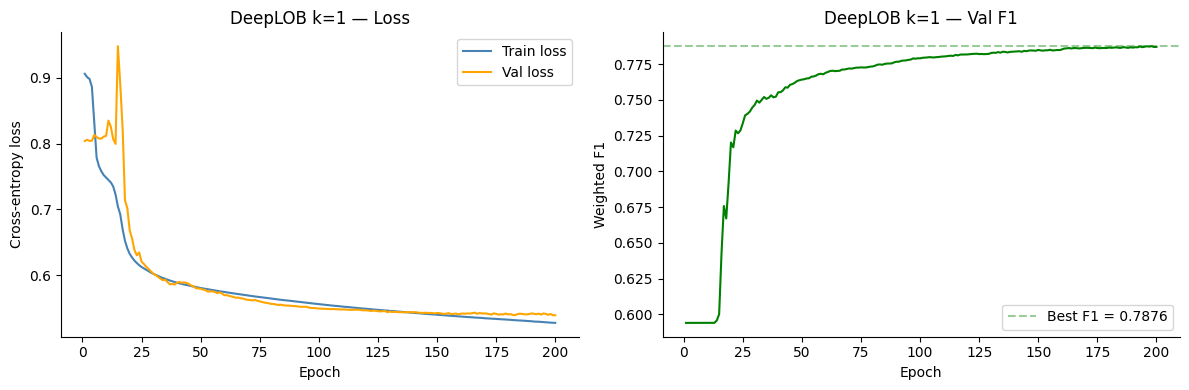


══════════ DeepLOB  k=2 ══════════
  epoch   1  tr_loss=1.0082  val_loss=0.9396  val_F1=0.4853  (12.6s)
  epoch   5  tr_loss=0.9523  val_loss=0.9363  val_F1=0.4853  (12.6s)
  epoch  10  tr_loss=0.8962  val_loss=0.9288  val_F1=0.4853  (12.7s)
  epoch  15  tr_loss=0.8737  val_loss=0.9282  val_F1=0.4853  (12.7s)
  epoch  20  tr_loss=0.8305  val_loss=0.9492  val_F1=0.4879  (12.9s)
  epoch  25  tr_loss=0.8005  val_loss=0.8418  val_F1=0.5841  (12.8s)
  epoch  30  tr_loss=0.7785  val_loss=0.7877  val_F1=0.6412  (12.8s)
  epoch  35  tr_loss=0.7678  val_loss=0.7663  val_F1=0.6553  (12.9s)
  epoch  40  tr_loss=0.7614  val_loss=0.7660  val_F1=0.6652  (12.9s)
  epoch  45  tr_loss=0.7569  val_loss=0.7673  val_F1=0.6681  (12.9s)
  epoch  50  tr_loss=0.7533  val_loss=0.7639  val_F1=0.6699  (12.8s)
  epoch  55  tr_loss=0.7500  val_loss=0.7667  val_F1=0.6713  (12.9s)
  epoch  60  tr_loss=0.7471  val_loss=0.7631  val_F1=0.6733  (12.8s)
  epoch  65  tr_loss=0.7445  val_loss=0.7664  val_F1=0.6737  (12.9s

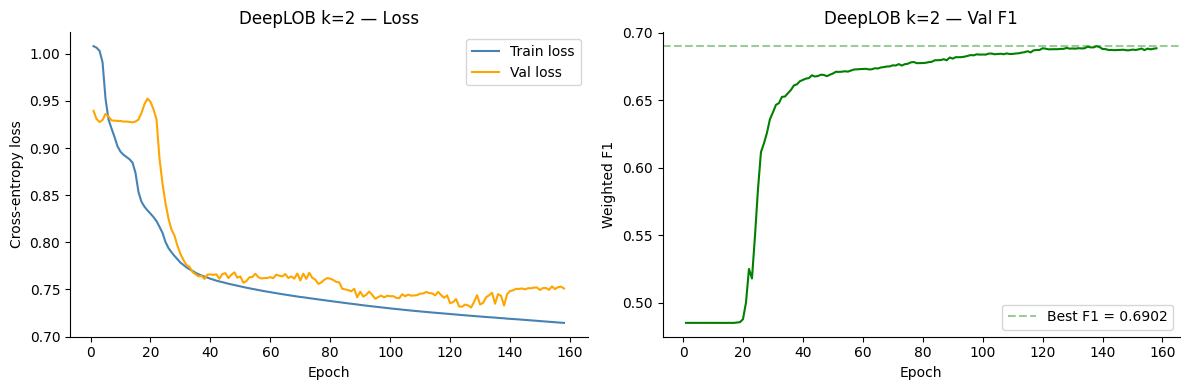


══════════ DeepLOB  k=3 ══════════
  epoch   1  tr_loss=1.0549  val_loss=0.9959  val_F1=0.4129  (12.9s)
  epoch   5  tr_loss=0.9573  val_loss=1.0156  val_F1=0.4707  (12.8s)
  epoch  10  tr_loss=0.8687  val_loss=0.8684  val_F1=0.5681  (12.9s)
  epoch  15  tr_loss=0.8366  val_loss=0.8117  val_F1=0.6084  (12.9s)
  epoch  20  tr_loss=0.8263  val_loss=0.7894  val_F1=0.6113  (12.9s)
  epoch  25  tr_loss=0.8205  val_loss=0.7883  val_F1=0.6263  (12.9s)
  epoch  30  tr_loss=0.7499  val_loss=0.7637  val_F1=0.6675  (12.9s)
  epoch  35  tr_loss=0.7261  val_loss=0.7504  val_F1=0.6755  (12.9s)
  epoch  40  tr_loss=0.7128  val_loss=0.7417  val_F1=0.6796  (12.9s)
  epoch  45  tr_loss=0.7024  val_loss=0.7317  val_F1=0.6875  (13.0s)
  epoch  50  tr_loss=0.6941  val_loss=0.7244  val_F1=0.6926  (12.9s)
  epoch  55  tr_loss=0.6871  val_loss=0.7249  val_F1=0.6938  (12.9s)
  epoch  60  tr_loss=0.6812  val_loss=0.7212  val_F1=0.6966  (12.9s)
  epoch  65  tr_loss=0.6759  val_loss=0.7169  val_F1=0.6984  (12.9s

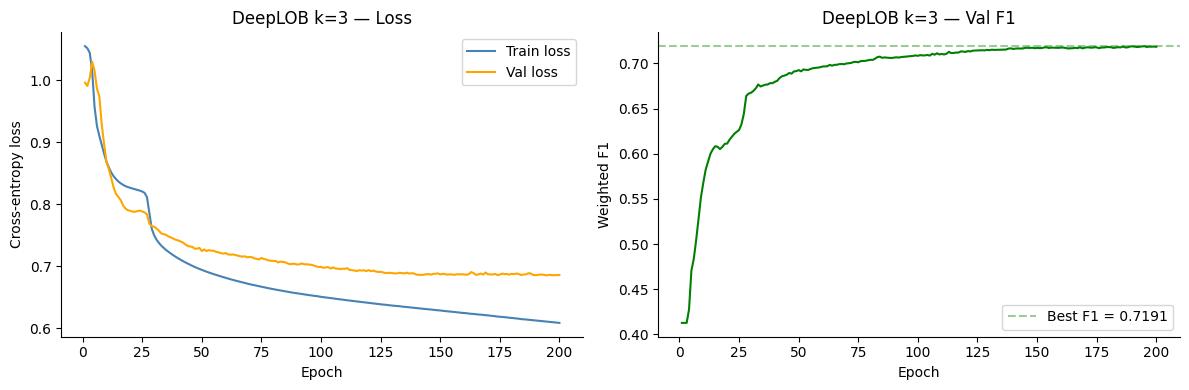


══════════ DeepLOB  k=5 ══════════
  epoch   1  tr_loss=1.0862  val_loss=1.0558  val_F1=0.3252  (13.1s)
  epoch   5  tr_loss=0.9152  val_loss=1.0559  val_F1=0.3252  (13.1s)
  epoch  10  tr_loss=0.8548  val_loss=1.0537  val_F1=0.3252  (13.1s)
  epoch  15  tr_loss=0.7779  val_loss=1.0544  val_F1=0.3252  (13.1s)
  epoch  20  tr_loss=0.7537  val_loss=1.0543  val_F1=0.3252  (13.1s)
  → early stop at epoch 21  best_F1=0.3252
  Saved → /home/users/mt487/deeplob-midprice-prediction/models/deeplob_k5.pt
  TEST  weighted_F1=0.2350  kappa=0.0000


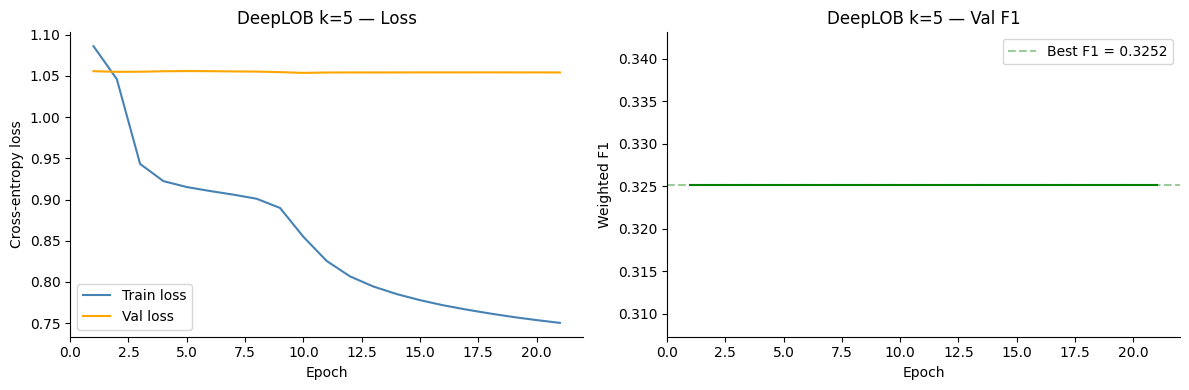


══════════ DeepLOB  k=10 ══════════
  epoch   1  tr_loss=1.0614  val_loss=1.1138  val_F1=0.1304  (13.1s)
  epoch   5  tr_loss=0.9083  val_loss=1.1049  val_F1=0.1642  (12.7s)
  epoch  10  tr_loss=0.8853  val_loss=1.1050  val_F1=0.1303  (12.7s)
  epoch  15  tr_loss=0.8770  val_loss=1.1043  val_F1=0.1302  (12.7s)
  epoch  20  tr_loss=0.8048  val_loss=1.1037  val_F1=0.1642  (12.7s)
  epoch  25  tr_loss=0.7504  val_loss=1.1038  val_F1=0.1642  (12.7s)
  → early stop at epoch 25  best_F1=0.1642
  Saved → /home/users/mt487/deeplob-midprice-prediction/models/deeplob_k10.pt
  TEST  weighted_F1=0.3384  kappa=0.1238


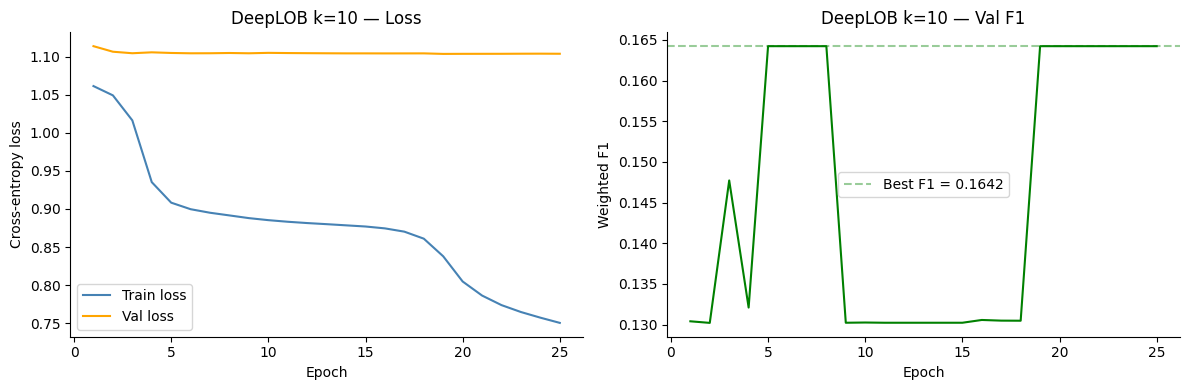

In [6]:
deeplob_results   = []
deeplob_histories = []

for h_idx, k in enumerate(HORIZONS):
    print(f'\n══════════ DeepLOB  k={k} ══════════')

    train_ds = SlidingWindowDataset(X_train, Y_train, window=WINDOW, horizon_idx=h_idx)
    val_ds   = SlidingWindowDataset(X_val,   Y_val,   window=WINDOW, horizon_idx=h_idx)
    test_ds  = SlidingWindowDataset(X_test,  Y_test,  window=WINDOW, horizon_idx=h_idx)

    train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
    val_loader   = make_loader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
    test_loader  = make_loader(test_ds,  batch_size=512,        shuffle=False)

    model = DeepLOB()
    best_state, history = train_neural(
        model, train_loader, val_loader,
        max_epochs=200, patience=20,
        lr=0.01, eps=1.0,
        device=DEVICE, verbose=True
    )

    # Save checkpoint
    ckpt_path = os.path.join(MODELS, f'deeplob_k{k}.pt')
    save_checkpoint(best_state, ckpt_path)
    print(f'  Saved → {ckpt_path}')

    # Evaluate on test set
    model.load_state_dict(best_state)
    model.eval().to(DEVICE)
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            all_preds.append(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
            all_labels.append(yb.numpy())
    import numpy as np
    preds  = np.concatenate(all_preds)
    labels = np.concatenate(all_labels)
    metrics = compute_metrics(labels, preds)
    deeplob_results.append(metrics)
    deeplob_histories.append(history)
    print(f'  TEST  weighted_F1={metrics["weighted_f1"]:.4f}  kappa={metrics["cohen_kappa"]:.4f}')

    plot_training_curves(history, 'DeepLOB', k,
                         save_path=os.path.join(RESULTS, f'deeplob_curves_k{k}.png'))

## 5b. Retrain DeepLOB — k=5 and k=10 only (patience=50, class weights)

k=5 and k=10 early-stopped at epoch 21/25 before breaking out of the majority-class plateau.
k=1 was also stuck for ~14 epochs before suddenly improving — k=5/10 needed more patience.
Fix: patience=50 + balanced class weights give stronger signal on minority (up/down) classes.
**Do NOT rerun the full loop above — only run this cell.**


══════════ DeepLOB  k=5  [RETRAIN — patience=50, class_weights] ══════════
  class weights: down=1.012  stat=0.960  up=1.031
  epoch   1  tr_loss=1.0905  val_loss=1.0729  val_F1=0.3252  (12.8s)
  epoch   5  tr_loss=0.9269  val_loss=1.0631  val_F1=0.4000  (12.6s)
  epoch  10  tr_loss=0.7987  val_loss=0.9890  val_F1=0.5132  (12.7s)
  epoch  15  tr_loss=0.7248  val_loss=0.8305  val_F1=0.6168  (12.7s)
  epoch  20  tr_loss=0.6874  val_loss=0.7980  val_F1=0.6482  (12.7s)
  epoch  25  tr_loss=0.6633  val_loss=0.7835  val_F1=0.6573  (12.6s)
  epoch  30  tr_loss=0.6457  val_loss=0.7733  val_F1=0.6687  (12.7s)
  epoch  35  tr_loss=0.6321  val_loss=0.7561  val_F1=0.6782  (12.7s)
  epoch  40  tr_loss=0.6217  val_loss=0.7463  val_F1=0.6840  (12.7s)
  epoch  45  tr_loss=0.6130  val_loss=0.7335  val_F1=0.6901  (12.7s)
  epoch  50  tr_loss=0.6055  val_loss=0.7279  val_F1=0.6945  (12.7s)
  epoch  55  tr_loss=0.5986  val_loss=0.7231  val_F1=0.6974  (12.6s)
  epoch  60  tr_loss=0.5924  val_loss=0.7184  

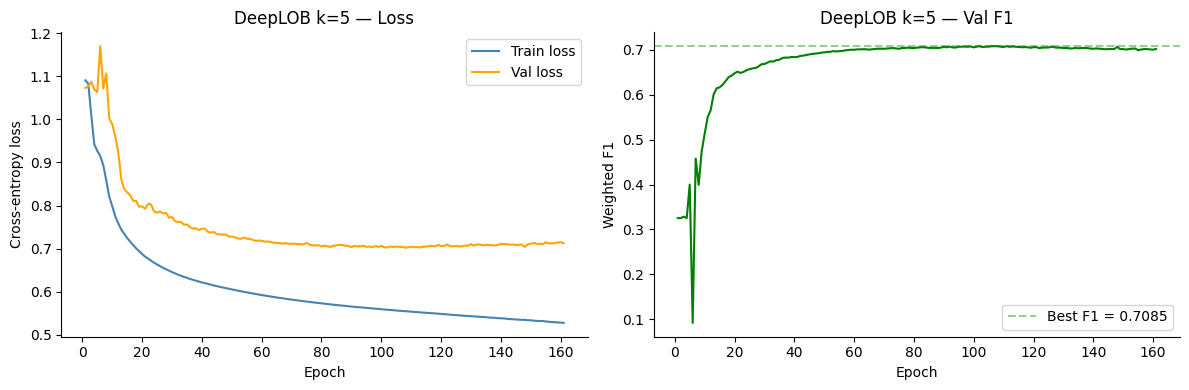


══════════ DeepLOB  k=10  [RETRAIN — patience=50, class_weights] ══════════
  class weights: down=0.847  stat=1.507  up=0.865
  epoch   1  tr_loss=1.0844  val_loss=1.0637  val_F1=0.2089  (12.8s)
  epoch   5  tr_loss=0.9102  val_loss=1.0562  val_F1=0.2089  (12.9s)
  epoch  10  tr_loss=0.8872  val_loss=1.0564  val_F1=0.2089  (13.0s)
  epoch  15  tr_loss=0.8769  val_loss=1.0560  val_F1=0.2089  (12.9s)
  epoch  20  tr_loss=0.8714  val_loss=1.0558  val_F1=0.2089  (12.9s)
  epoch  25  tr_loss=0.8625  val_loss=1.0547  val_F1=0.2089  (12.8s)
  epoch  30  tr_loss=0.7991  val_loss=1.0550  val_F1=0.2089  (12.8s)
  epoch  35  tr_loss=0.7641  val_loss=1.0561  val_F1=0.2089  (12.8s)
  epoch  40  tr_loss=0.7428  val_loss=1.0565  val_F1=0.2089  (12.9s)
  epoch  45  tr_loss=0.7256  val_loss=1.0567  val_F1=0.2089  (12.9s)
  epoch  50  tr_loss=0.7111  val_loss=1.0568  val_F1=0.2089  (12.9s)
  → early stop at epoch 51  best_F1=0.2089
  Saved → /home/users/mt487/deeplob-midprice-prediction/models/deeplob_

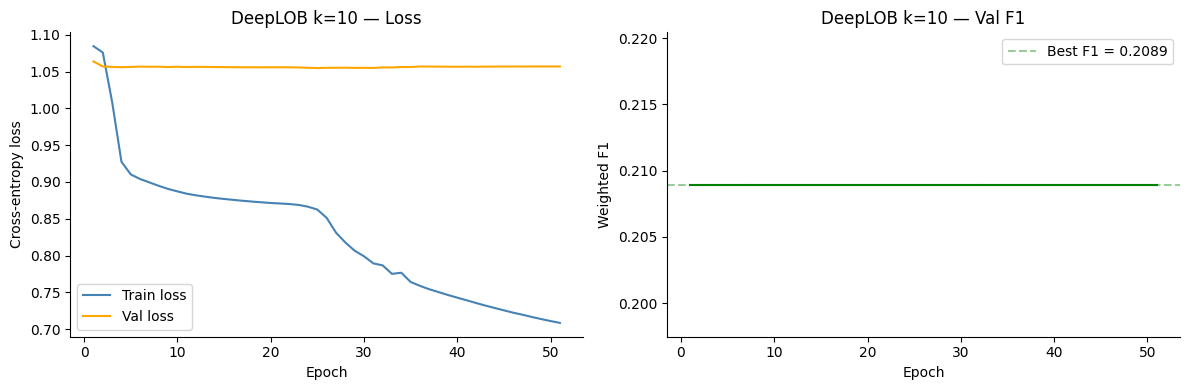

In [8]:
import pickle
from sklearn.utils.class_weight import compute_class_weight

for h_idx, k in [(3, 5), (4, 10)]:
    print(f'\n══════════ DeepLOB  k={k}  [RETRAIN — patience=50, class_weights] ══════════')

    cw = compute_class_weight('balanced', classes=np.array([0, 1, 2]), y=Y_train[:, h_idx])
    class_weights = torch.FloatTensor(cw)
    print(f'  class weights: down={cw[0]:.3f}  stat={cw[1]:.3f}  up={cw[2]:.3f}')

    train_ds = SlidingWindowDataset(X_train, Y_train, window=WINDOW, horizon_idx=h_idx)
    val_ds   = SlidingWindowDataset(X_val,   Y_val,   window=WINDOW, horizon_idx=h_idx)
    test_ds  = SlidingWindowDataset(X_test,  Y_test,  window=WINDOW, horizon_idx=h_idx)

    train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
    val_loader   = make_loader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
    test_loader  = make_loader(test_ds,  batch_size=512,        shuffle=False)

    model = DeepLOB()
    best_state, history = train_neural(
        model, train_loader, val_loader,
        max_epochs=200, patience=50,
        lr=0.01, eps=1.0,
        class_weights=class_weights,
        device=DEVICE, verbose=True
    )

    ckpt_path = os.path.join(MODELS, f'deeplob_k{k}.pt')
    save_checkpoint(best_state, ckpt_path)
    print(f'  Saved → {ckpt_path}')

    model.load_state_dict(best_state)
    model.eval().to(DEVICE)
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            all_preds.append(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
            all_labels.append(yb.numpy())
    preds  = np.concatenate(all_preds)
    labels = np.concatenate(all_labels)
    metrics = compute_metrics(labels, preds)

    pos = HORIZONS.index(k)
    deeplob_results[pos]   = metrics
    deeplob_histories[pos] = history
    print(f'  TEST  weighted_F1={metrics["weighted_f1"]:.4f}  kappa={metrics["cohen_kappa"]:.4f}')

    plot_training_curves(history, 'DeepLOB', k,
                         save_path=os.path.join(RESULTS, f'deeplob_curves_k{k}.png'))

# Re-save pkl with corrected k=5 and k=10
neural_results = {
    'lstm':              lstm_results,
    'deeplob':           deeplob_results,
    'lstm_histories':    lstm_histories,
    'deeplob_histories': deeplob_histories,
}
with open(os.path.join(RESULTS, 'neural_results.pkl'), 'wb') as f:
    pickle.dump(neural_results, f)
print('Updated results/neural_results.pkl')


## 5c. Retrain DeepLOB — k=10 only (lr=0.001, class weights)

In [10]:
from sklearn.utils.class_weight import compute_class_weight

h_idx, k = 4, 10
cw = compute_class_weight('balanced', classes=np.array([0, 1, 2]), y=Y_train[:, h_idx])
class_weights = torch.FloatTensor(cw)

train_ds = SlidingWindowDataset(X_train, Y_train, window=WINDOW, horizon_idx=h_idx)
val_ds   = SlidingWindowDataset(X_val,   Y_val,   window=WINDOW, horizon_idx=h_idx)
test_ds  = SlidingWindowDataset(X_test,  Y_test,  window=WINDOW, horizon_idx=h_idx)

train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
val_loader   = make_loader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = make_loader(test_ds,  batch_size=512,        shuffle=False)

model = DeepLOB()
best_state, history = train_neural(
    model, train_loader, val_loader,
    max_epochs=200, patience=50,
    lr=0.001, eps=1.0,           # 10x lower lr
    class_weights=class_weights,
    device=DEVICE, verbose=True
)

ckpt_path = os.path.join(MODELS, 'deeplob_k10.pt')
save_checkpoint(best_state, ckpt_path)

model.load_state_dict(best_state)
model.eval().to(DEVICE)
all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        all_preds.append(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
        all_labels.append(yb.numpy())
preds  = np.concatenate(all_preds)
labels = np.concatenate(all_labels)
m = compute_metrics(labels, preds)
deeplob_results[4] = m
deeplob_histories[4] = history
print(f'k=10  TEST  F1={m["weighted_f1"]:.4f}  kappa={m["cohen_kappa"]:.4f}')


  epoch   1  tr_loss=1.0997  val_loss=1.0934  val_F1=0.2095  (12.9s)
  epoch   5  tr_loss=1.0975  val_loss=1.1000  val_F1=0.1581  (12.9s)
  epoch  10  tr_loss=1.0953  val_loss=1.0950  val_F1=0.2699  (12.9s)
  epoch  15  tr_loss=1.0783  val_loss=1.0634  val_F1=0.2089  (12.9s)
  epoch  20  tr_loss=0.9972  val_loss=1.0588  val_F1=0.2089  (12.9s)
  epoch  25  tr_loss=0.9443  val_loss=1.0535  val_F1=0.2089  (12.9s)
  epoch  30  tr_loss=0.9223  val_loss=1.0523  val_F1=0.2089  (12.9s)
  epoch  35  tr_loss=0.9113  val_loss=1.0554  val_F1=0.2089  (12.9s)
  epoch  40  tr_loss=0.9044  val_loss=1.0550  val_F1=0.2089  (12.9s)
  epoch  45  tr_loss=0.8999  val_loss=1.0564  val_F1=0.2089  (12.9s)
  epoch  50  tr_loss=0.8963  val_loss=1.0579  val_F1=0.2089  (13.2s)
  epoch  55  tr_loss=0.8935  val_loss=1.0584  val_F1=0.2089  (13.2s)
  → early stop at epoch 59  best_F1=0.3352
k=10  TEST  F1=0.3406  kappa=0.0521


### DeepLOB — results across horizons

In [11]:
print('DeepLOB — weighted F1 on test set:')
print('  (Paper Table II Setup 2 comparison: k=10 → F1=0.834)')
for k, m in zip(HORIZONS, deeplob_results):
    paper_note = '  ← compare to paper 0.834' if k == 10 else ''
    print(f'  k={k:>2}  F1={m["weighted_f1"]:.4f}  kappa={m["cohen_kappa"]:.4f}{paper_note}')

DeepLOB — weighted F1 on test set:
  (Paper Table II Setup 2 comparison: k=10 → F1=0.834)
  k= 1  F1=0.7888  kappa=0.5580
  k= 2  F1=0.6844  kappa=0.4428
  k= 3  F1=0.7273  kappa=0.5566
  k= 5  F1=0.7404  kappa=0.6055
  k=10  F1=0.3406  kappa=0.0521  ← compare to paper 0.834


## 6. Save neural results for notebook 04

In [15]:
lstm_results    = []
deeplob_results = []

for h_idx, k in enumerate(HORIZONS):
    test_ds     = SlidingWindowDataset(X_test, Y_test, window=WINDOW, horizon_idx=h_idx)
    test_loader = make_loader(test_ds, batch_size=512, shuffle=False)

    for ModelClass, results_list, fname in [
        (SimpleLSTM, lstm_results,    f"lstm_k{k}.pt"),
        (DeepLOB,    deeplob_results, f"deeplob_k{k}.pt"),
    ]:
        m = load_checkpoint(ModelClass(), os.path.join(MODELS, fname)).eval().to(DEVICE)
        preds, labels = [], []
        with torch.no_grad():
            for X_b, y_b in test_loader:
                preds.append(m(X_b.to(DEVICE)).argmax(dim=1).cpu().numpy())
                labels.append(y_b.cpu().numpy())
        y_pred = np.concatenate(preds)
        y_true = np.concatenate(labels)
        metrics = compute_metrics(y_true, y_pred)
        metrics["k"] = k
        results_list.append(metrics)
        print(f"  k={k:2d}  {fname.split('_')[0]:8s}  F1={metrics['weighted_f1']:.3f}  κ={metrics['cohen_kappa']:.3f}")

os.makedirs("../results", exist_ok=True)
with open("../results/neural_results.pkl", "wb") as f:
    pickle.dump({"lstm": lstm_results, "deeplob": deeplob_results}, f)
print("\nSaved → results/neural_results.pkl")


  k= 1  lstm      F1=0.767  κ=0.512
  k= 1  deeplob   F1=0.789  κ=0.558
  k= 2  lstm      F1=0.655  κ=0.392
  k= 2  deeplob   F1=0.684  κ=0.443
  k= 3  lstm      F1=0.682  κ=0.482
  k= 3  deeplob   F1=0.727  κ=0.557
  k= 5  lstm      F1=0.696  κ=0.537
  k= 5  deeplob   F1=0.740  κ=0.606
  k=10  lstm      F1=0.647  κ=0.468
  k=10  deeplob   F1=0.341  κ=0.052

Saved → results/neural_results.pkl


In [17]:
import pickle

# lstm_histories lost to kernel crash; deeplob_histories lost for k=5/k=10 retrain cells
neural_results = {
    'lstm':              lstm_results,
    'deeplob':           deeplob_results,
    'lstm_histories':    {},   # unavailable — kernel crashed during LSTM training
    'deeplob_histories': {},   # unavailable — k=5/k=10 retrained separately
}

with open(os.path.join(RESULTS, 'neural_results.pkl'), 'wb') as f:
    pickle.dump(neural_results, f)

print('Saved to results/neural_results.pkl')
for f in sorted(os.listdir(MODELS)):
    if f.endswith('.pt'):
        path = os.path.join(MODELS, f)
        print(f'  {f}  ({os.path.getsize(path) / 1024:.0f} KB)')


Saved to results/neural_results.pkl
  deeplob_k1.pt  (250 KB)
  deeplob_k10.pt  (250 KB)
  deeplob_k2.pt  (250 KB)
  deeplob_k3.pt  (250 KB)
  deeplob_k5.pt  (250 KB)
  lstm_k1.pt  (239 KB)
  lstm_k10.pt  (239 KB)
  lstm_k2.pt  (239 KB)
  lstm_k3.pt  (239 KB)
  lstm_k5.pt  (239 KB)
